1. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Choose a results folder on your Drive.

In [4]:
DRIVE_RESULTS = "/content/drive/MyDrive/arithmetic-geometry-results"
import os
os.makedirs(DRIVE_RESULTS, exist_ok=True)

3. Clone repo (fresh each session) and install

In [5]:
!git clone https://github.com/netajik/Arithmetic-Geometry /content/arithmetic-geometry
%cd /content/arithmetic-geometry
# if your work is on another branch:
!git checkout colab-setup
!pip install -q torch numpy matplotlib pyyaml transformers accelerate

Cloning into '/content/arithmetic-geometry'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 56 (delta 16), reused 55 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 1.79 MiB | 5.70 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/arithmetic-geometry
Branch 'colab-setup' set up to track remote branch 'colab-setup' from 'origin'.
Switched to a new branch 'colab-setup'


4. Build Colab config that points only to Drive


5. Log in to Hugging Face (for Llama)

Paste your Hugging Face token when prompted. (Get a token at huggingface.co/settings/tokens. Accept the Llama 3.1 8B license on the model page first.)

In [6]:
import os
import yaml
from huggingface_hub import snapshot_download, login
from google.colab import userdata

# 1) Log in (required for gated Llama)
login(token=userdata.get("HF_TOKEN"))

# 2) Model on RUNTIME only (re-download each session)
RUNTIME_MODEL = "/content/arithmetic-geometry/model"  # or "/content/model"
HF_REPO_ID = "meta-llama/Meta-Llama-3.1-8B"

os.makedirs(RUNTIME_MODEL, exist_ok=True)
snapshot_download(HF_REPO_ID, local_dir=RUNTIME_MODEL)

# 3) Results on Drive (persist)
DRIVE_RESULTS = "/content/drive/MyDrive/arithmetic-geometry-results"
os.makedirs(DRIVE_RESULTS, exist_ok=True)

# 4) Build config: model = runtime, outputs = Drive
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)
cfg["paths"]["workspace"] = DRIVE_RESULTS
cfg["paths"]["data_root"] = os.path.join(DRIVE_RESULTS, "data")
cfg["model"]["name"] = RUNTIME_MODEL

# If you get out of memory or want test quickly, in a new cell change the config
# and re-run step 4 before running the pipeline again, e.g.:
# cfg["generation"]["batch_size"] = 8
# cfg["dataset"]["problems_per_level"] = 500

with open("config_colab.yaml", "w") as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

print("Model on runtime; results will go to Drive.")

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Model on runtime; results will go to Drive.


5. Run pipeline and analysis

In [7]:
!python pipeline.py --config config_colab.yaml

10:11:23 | INFO    | ============================================================
10:11:23 | INFO    | Arithmetic Geometry Pipeline
10:11:23 | INFO    | ============================================================
10:11:23 | INFO    | --- Generating problems ---
10:11:23 | INFO    | Level 1: 64 problems (64 unique), a in [2,9], b in [2,9]
10:11:23 | INFO    | Level 2: 4000 problems (718 unique), a in [10,99], b in [2,9]
10:11:23 | INFO    | Level 3: 4000 problems (3174 unique), a in [10,99], b in [10,99]
10:11:23 | INFO    | Level 4: 4000 problems (3897 unique), a in [100,999], b in [10,99]
10:11:23 | INFO    | Level 5: 4000 problems (3992 unique), a in [100,999], b in [100,999]
10:11:23 | INFO    | Total problems across all levels: 16064
10:11:23 | INFO    | --- Computing labels ---
10:11:23 | INFO    | Level 1: computed 64 label sets
10:11:23 | INFO    | Level 2: computed 4000 label sets
10:11:23 | INFO    | Level 3: computed 4000 label sets
10:11:23 | INFO    | Level 4: computed 400

7. Run analysis (no GPU)

In [8]:
!python analysis.py --config config_colab.yaml


12:38:51 | INFO    | ============================================================
12:38:51 | INFO    | Arithmetic Geometry Error Analysis
12:38:51 | INFO    | ============================================================
12:38:51 | INFO    | --- Loading data ---
12:38:51 | INFO    | Level 1: 64 results, accuracy 100.0% (64/64)
12:38:51 | INFO    | Level 2: 4000 results, accuracy 99.3% (3972/4000)
12:38:51 | INFO    | Level 3: 4000 results, accuracy 65.8% (2630/4000)
12:38:51 | INFO    | Level 4: 4000 results, accuracy 28.9% (1156/4000)
12:38:51 | INFO    | Level 5: 4000 results, accuracy 6.0% (240/4000)
12:38:51 | INFO    | Level 1: loaded 64 label sets
12:38:51 | INFO    | Level 2: loaded 4000 label sets
12:38:51 | INFO    | Level 3: loaded 4000 label sets
12:38:51 | INFO    | Level 4: loaded 4000 label sets
12:38:51 | INFO    | Level 5: loaded 4000 label sets
12:38:51 | INFO    | Level 1: merged 64 entries
12:38:51 | INFO    | Level 2: merged 4000 entries
12:38:51 | INFO    | Level 3:

8. View plots

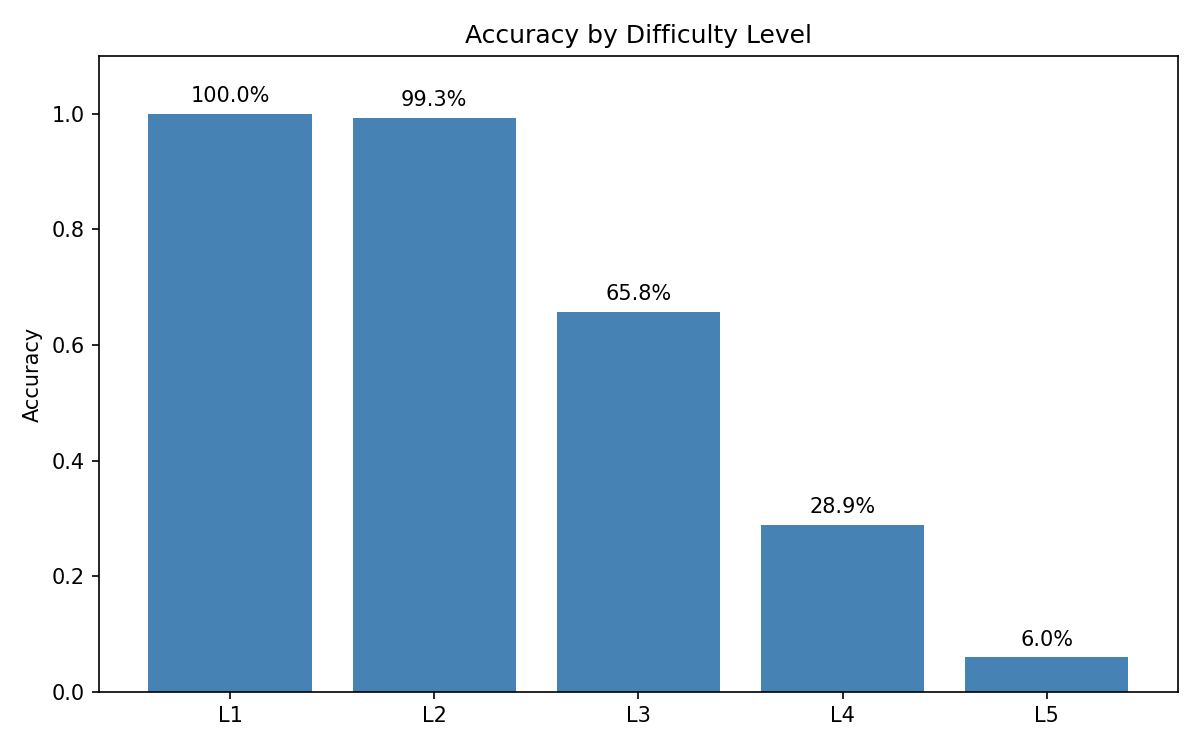

accuracy_by_level.png


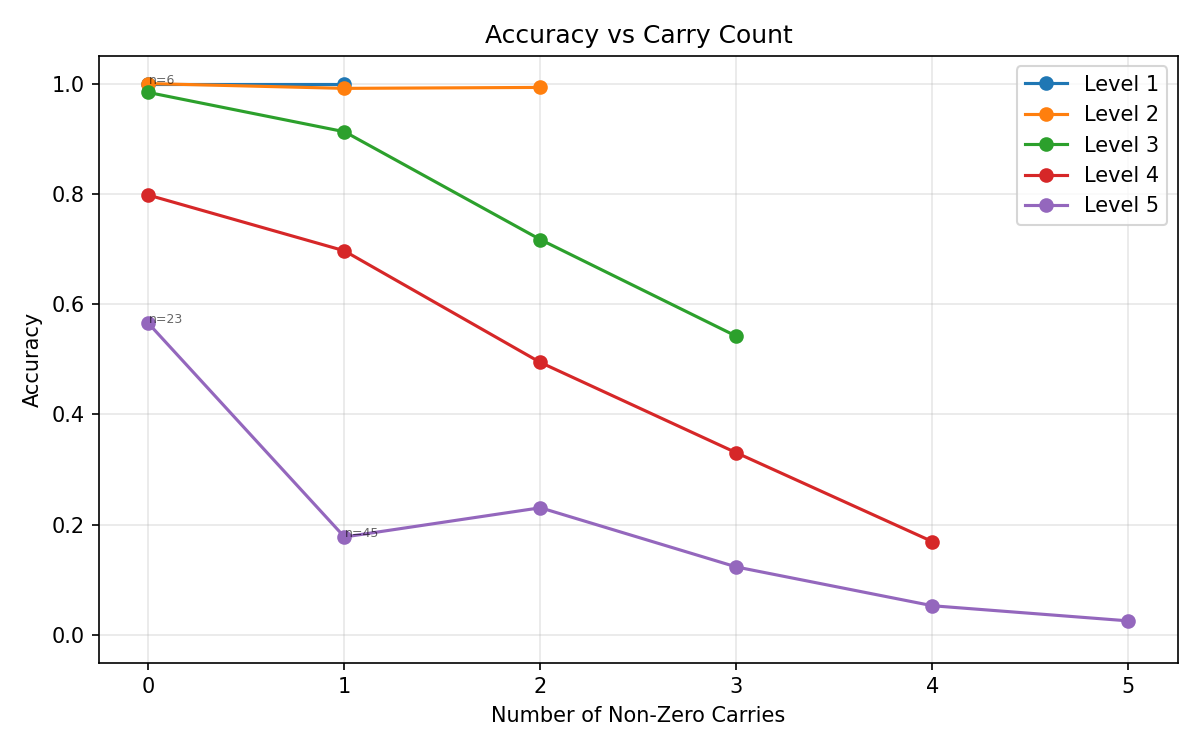

accuracy_vs_carries.png


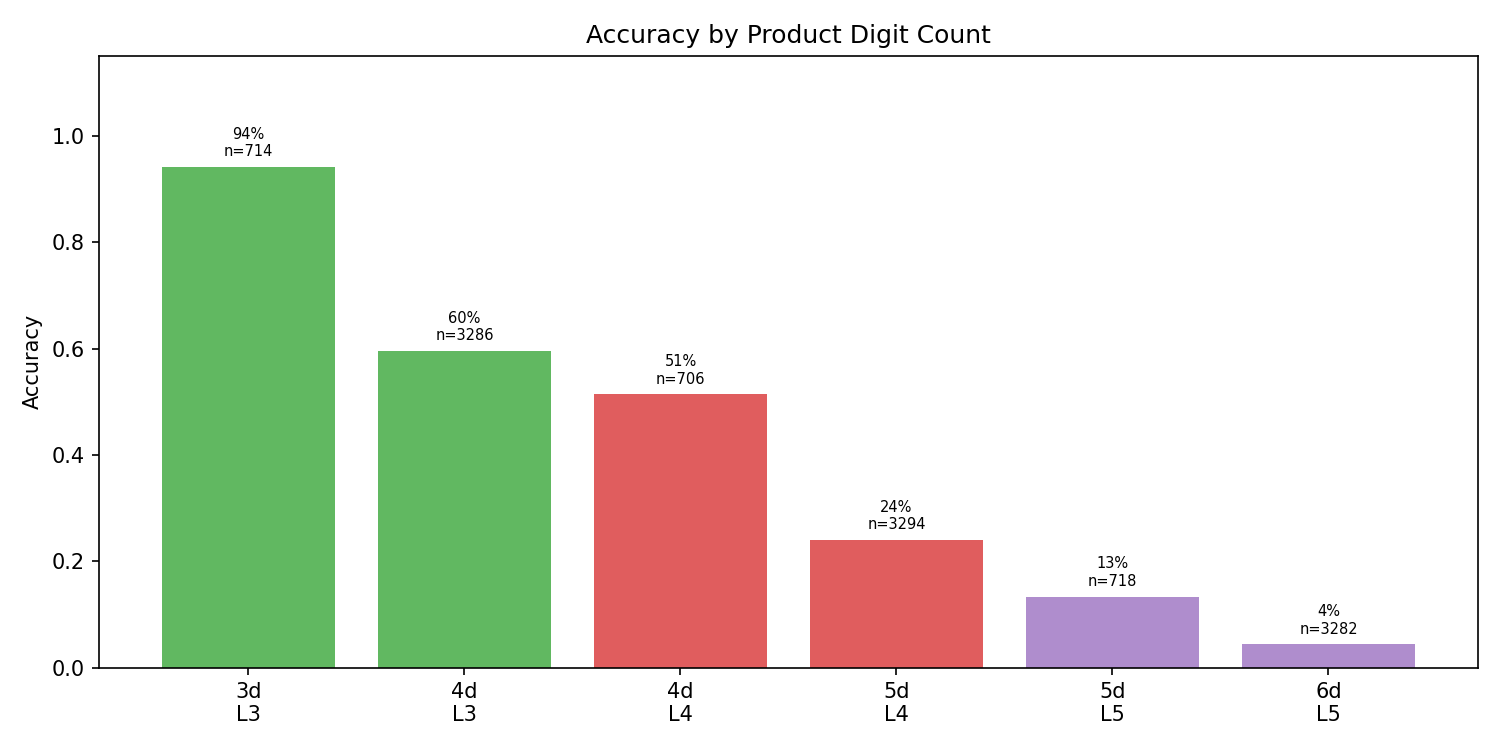

accuracy_vs_magnitude.png


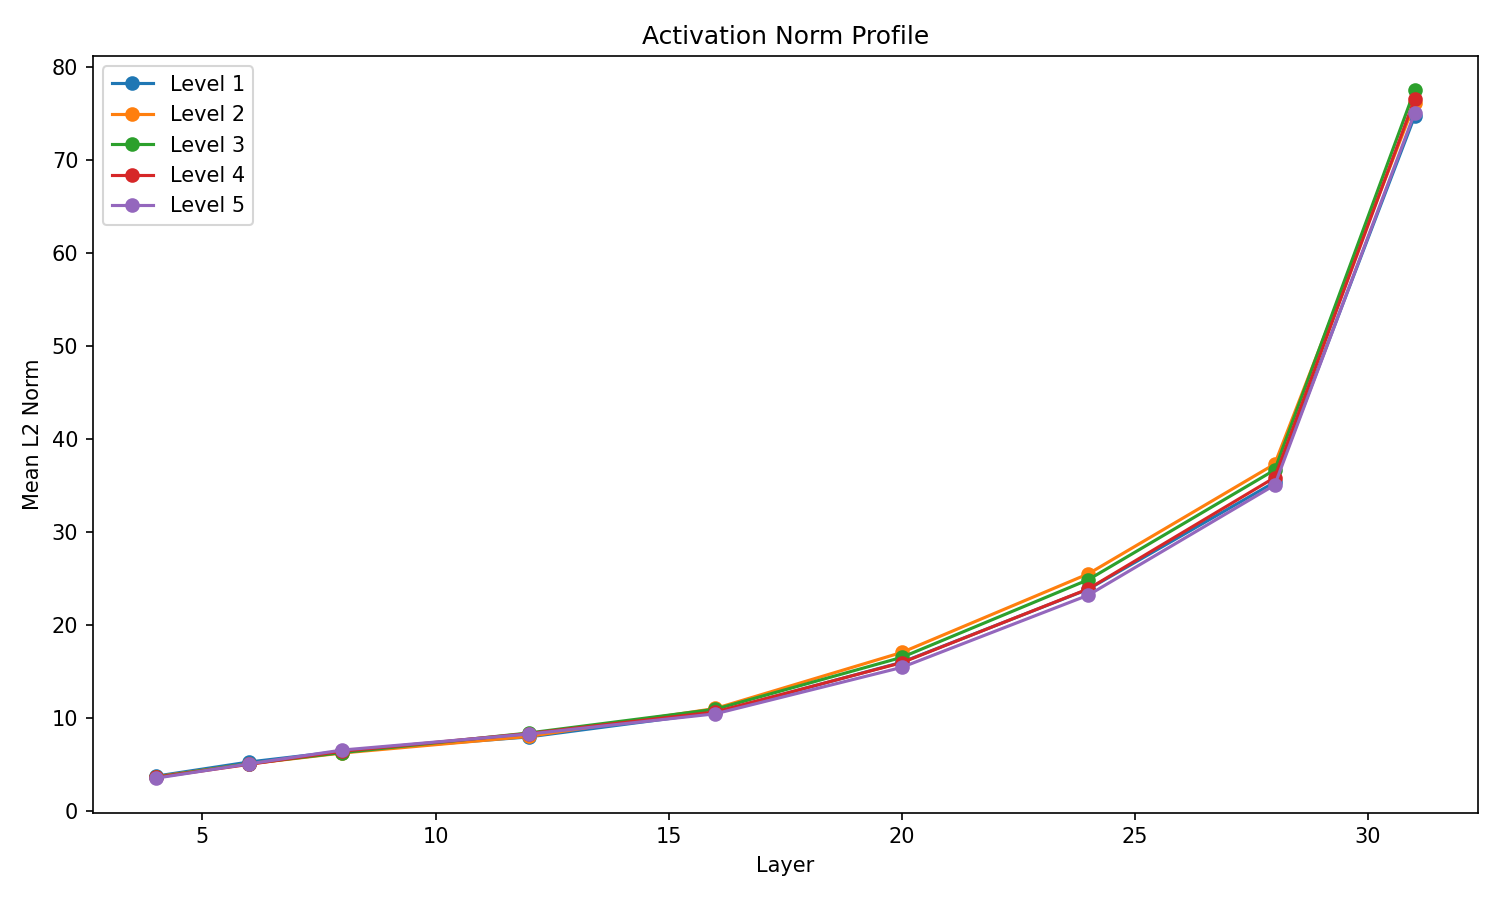

activation_norm_profile.png


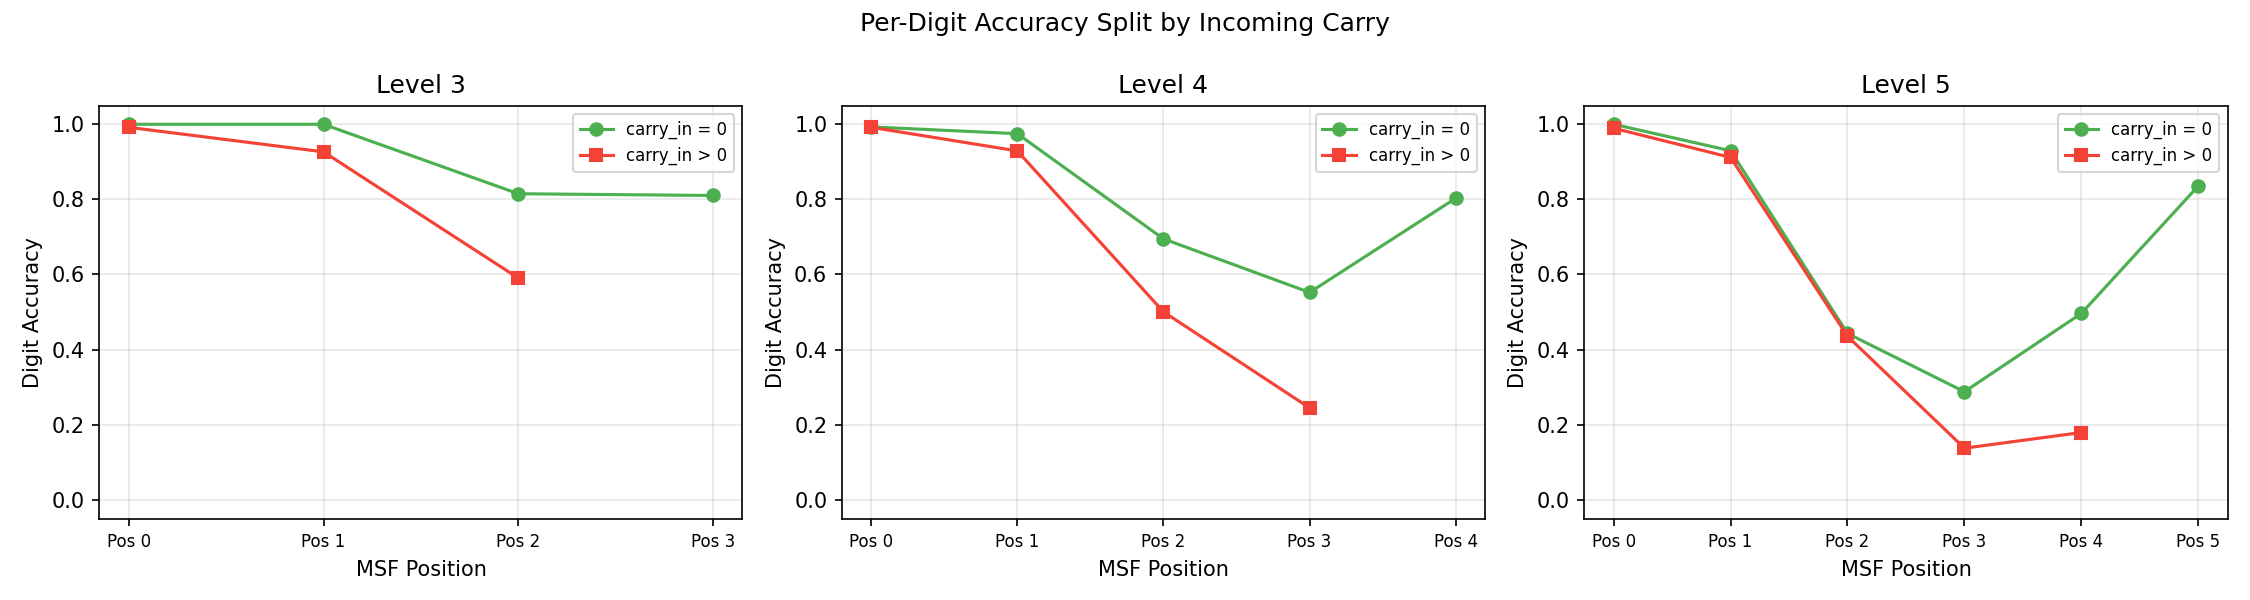

digit_accuracy_by_carry.png


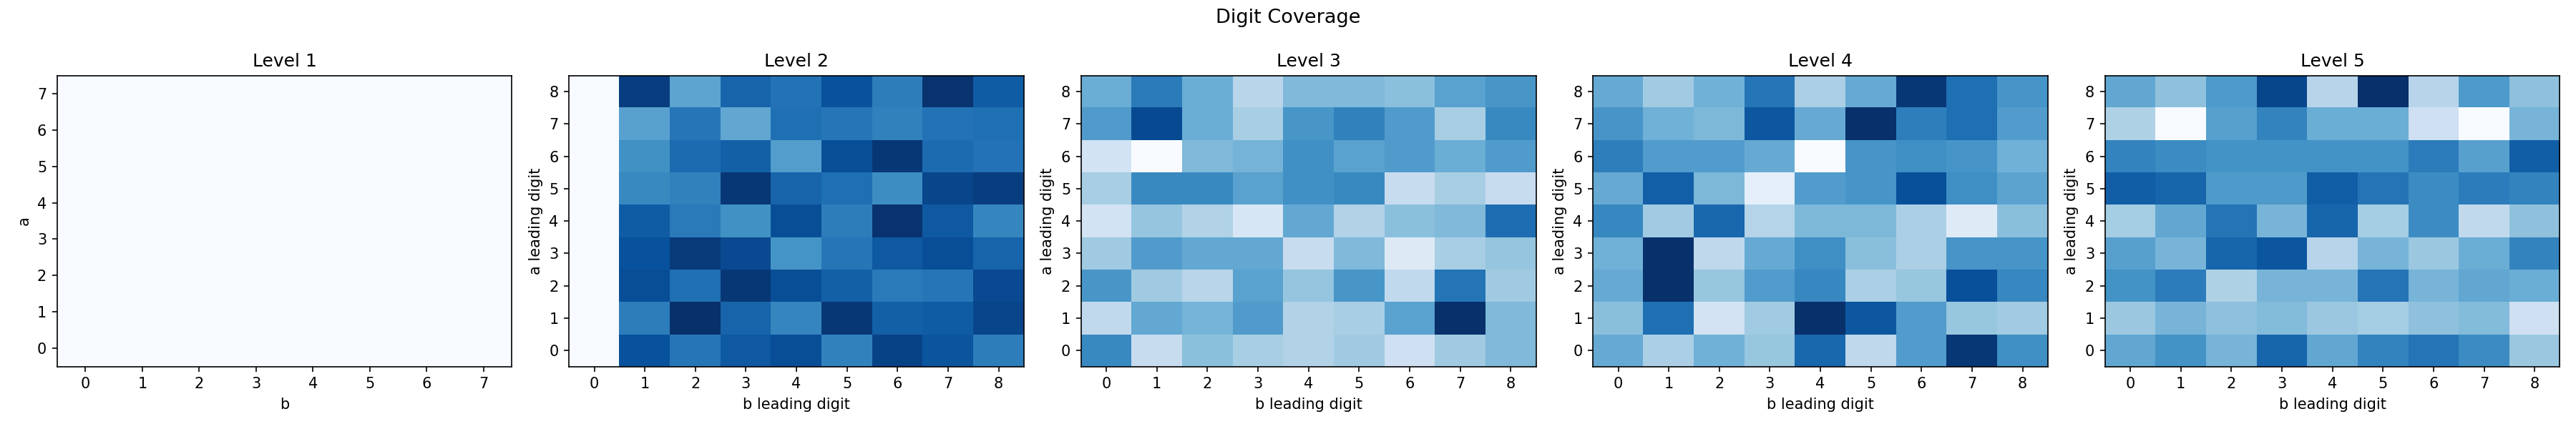

digit_coverage.png


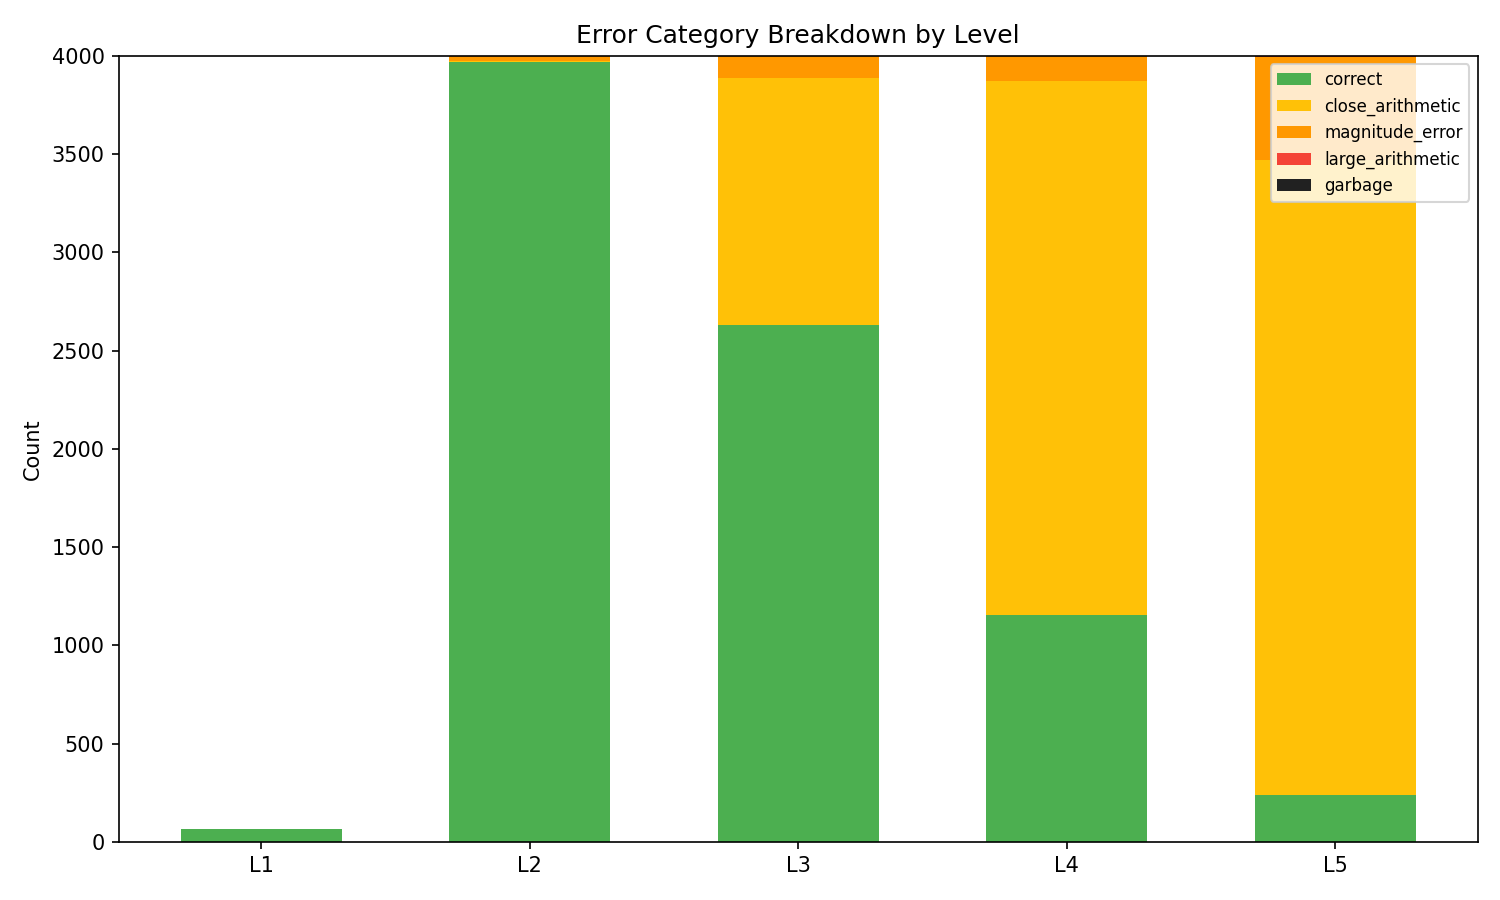

error_categories.png


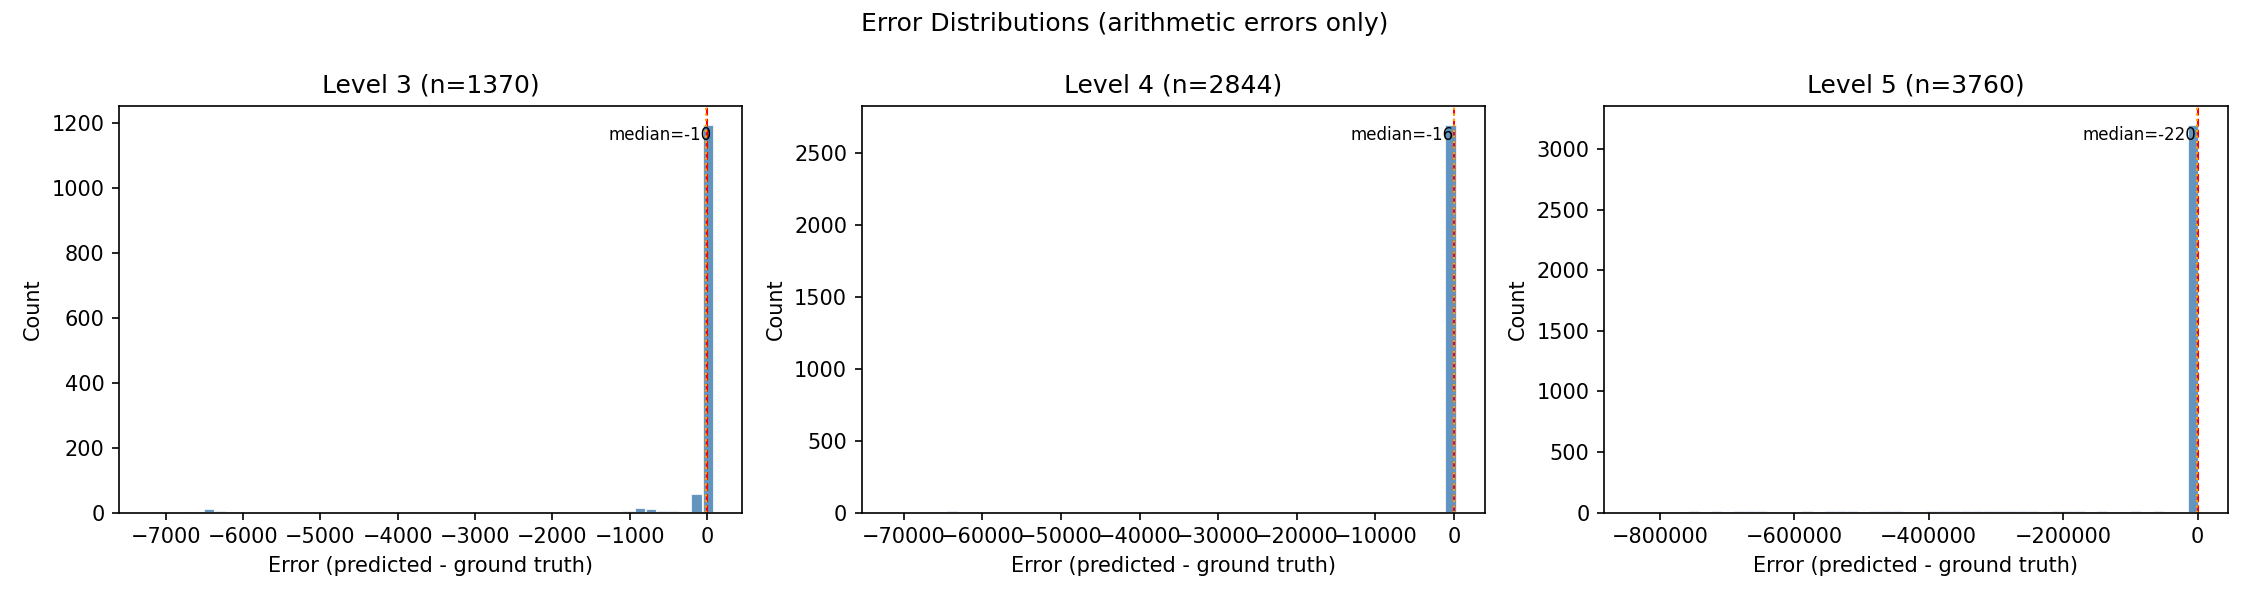

error_distributions.png


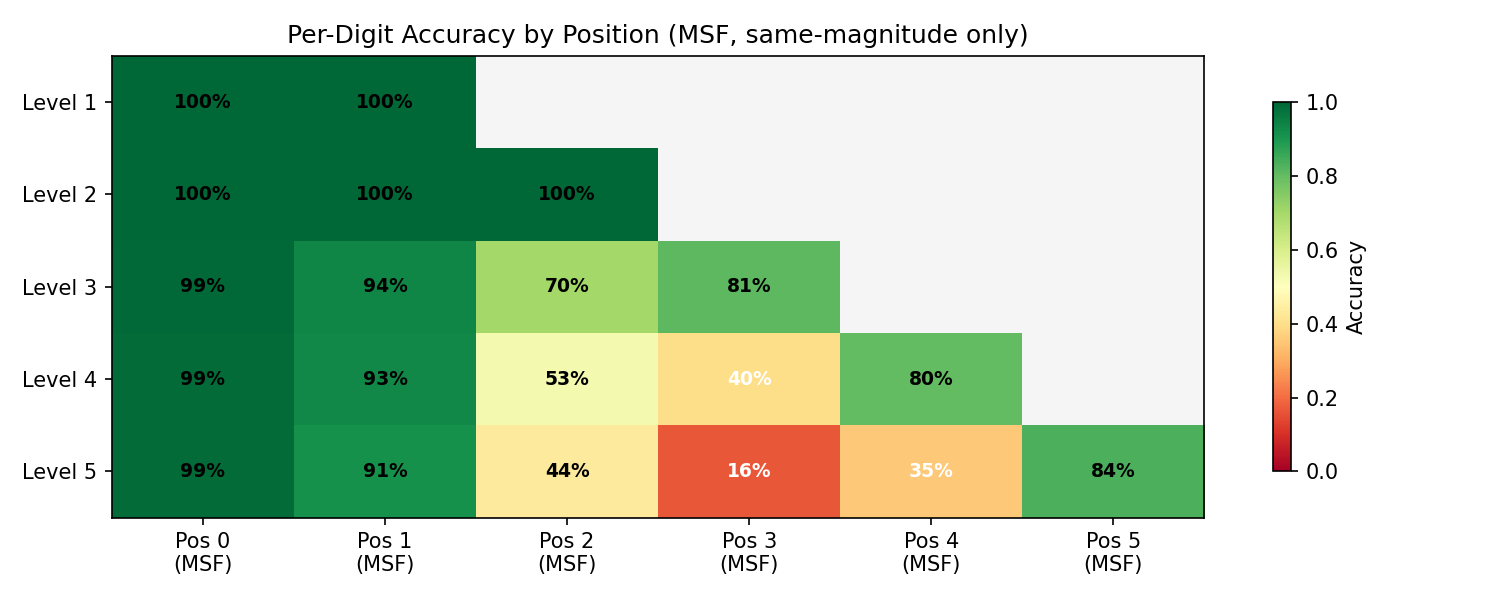

per_digit_accuracy_heatmap.png


In [9]:
from IPython.display import Image, display
for name in sorted(os.listdir(os.path.join(DRIVE_RESULTS, "plots"))):
    if name.endswith(".png"):
        display(Image(os.path.join(DRIVE_RESULTS, "plots", name), width=500))
        print(name)